<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 학습 목표
- K-NN 알고리즘의 기본 원리와 작동 방식 이해
- 거리 측정 방법과 K값 선택의 중요성 학습
- 분류와 회귀 문제에 K-NN 적용 방법 습득
- Python을 통한 K-NN 구현 및 최적화

## 핵심 개념 및 이론

### 1. K-NN이란?
K-NN(K-Nearest Neighbors)은 새로운 데이터 포인트를 분류할 때 가장 가까운 K개의 이웃 데이터의 레이블을 기반으로 결정하는 알고리즘입니다.   

"유유상종" 원리에 기반한 직관적인 방법입니다.

### 2. 핵심 아이디어
- **근접성 가정**: 비슷한 특성을 가진 데이터는 같은 클래스에 속할 가능성이 높다
- **게으른 학습(Lazy Learning)**: 훈련 단계에서는 데이터를 저장만 하고, 예측 시점에 계산 수행
- **비모수적 방법**: 데이터 분포에 대한 가정 없이 작동

### 3. 알고리즘 작동 과정
1. **거리 계산**: 새로운 데이터와 모든 훈련 데이터 간의 거리 계산
2. **이웃 선택**: 거리가 가까운 K개의 데이터 포인트 선택
3. **예측**: 선택된 이웃들의 레이블로 다수결 투표(분류) 또는 평균(회귀)
----
### 1. Model-based Learning (모델 기반 학습)

- **개념**: 데이터를 통해 **모델을 생성**하고, 이 모델을 이용해 분류/예측을 수행
    
- **대표 알고리즘**:
    
    - 선형/비선형 모델 (예: Linear Regression, Logistic Regression)
    - Neural Network (신경망)
    - Decision Tree (의사결정나무)
    - Support Vector Machine (SVM)
        
- **특징**:
    
    - 데이터를 일반화하여 **함수 f(X)** 형태의 모델을 만든 뒤 예측 수행


### 2. Instance-based Learning (사례 기반 학습)

- **개념**: 별도의 모델을 만들지 않고, **기존 데이터(인스턴스)와의 유사도**를 기준으로 분류/예측
    
- **대표 알고리즘**:
    
    - K-Nearest Neighbor (KNN)
    - Locally Weighted Regression
        
- **특징**:
    
    - 학습 시 모델을 생성하지 않음
    - 예측 시 새로운 데이터와 **저장된 데이터 간 거리(유사도)**를 활용


# 거리 측정 방법은?

# 수학적 기초

### 1. 거리 측정 방법

**유클리드 거리 (Euclidean Distance)**
```
d(x, y) = √(Σ(xi - yi)²)
```

**맨해튼 거리 (Manhattan Distance)**
```
d(x, y) = Σ|xi - yi|
```

**민코프스키 거리 (Minkowski Distance)**

$d(x, y) = (Σ|xi - yi|^p)^(1/p)$

- p=1: 맨해튼 거리
- p=2: 유클리드 거리

**코사인 유사도 (Cosine Similarity)**
```
similarity = (x·y) / (||x|| × ||y||)
distance = 1 - similarity
```


민코프스거리 수식 check

민코프스키 거리
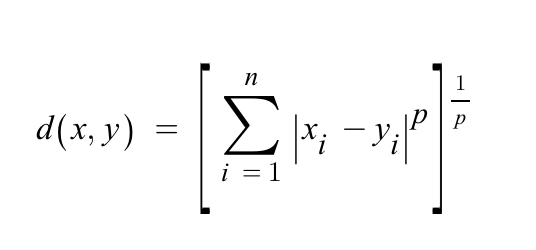

-----

# 라이브러리 불러오기!!

데이터 분석도구

In [ ]:
import numpy as np
import pandas as pd

라이브러리 머신러닝(sklearn)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix#classification_report 분류모델 결과 확인
from  sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, make_classification

시각화도구

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

-----

# 데이터 불러오기!! 및 전처리

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

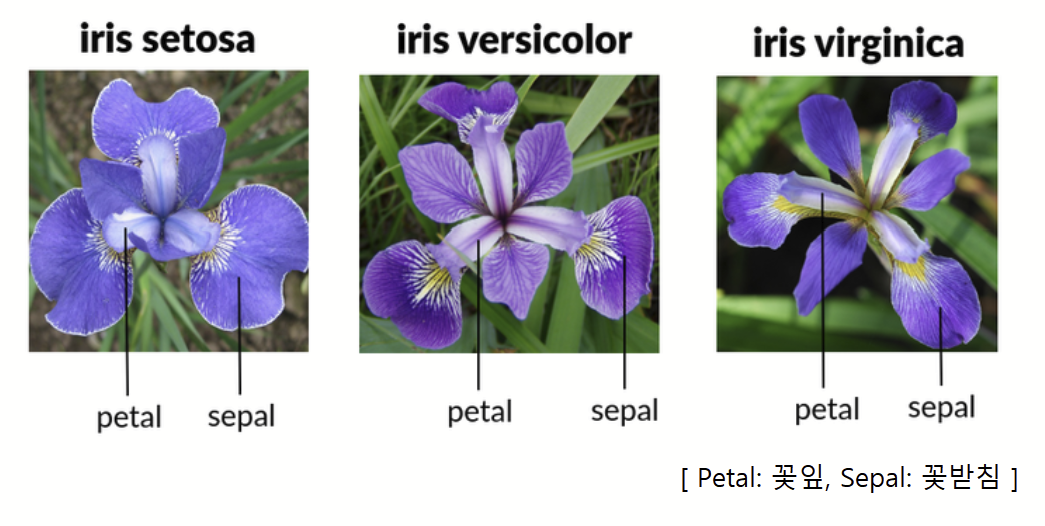

### 데이터셋 세부 정보
데이터 수: 총 150개 샘플 (각 품종당 50개).  
품종(Label): Setosa, Versicolor, Virginica.  
특징(Feature - 4개):  
꽃받침 길이 (Sepal Length)  
꽃받침 너비 (Sepal Width)  
꽃잎 길이 (Petal Length)   
꽃잎 너비 (Petal Width)  
활용: 머신러닝 및 데이터 분석 실습 (분류 알고리즘, 데이터 시각화).   

In [ ]:
y


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### 데이터 분할

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X ,y , test_size=0.2) #test_size=0.2 일부를 떼놓을 수 있음

In [ ]:
y_train

array([0, 2, 0, 1, 0, 0, 1, 2, 1, 0, 1, 0, 1, 2, 2, 1, 0, 1, 2, 0, 0, 2,
       2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 0, 0, 1, 2, 0, 2,
       1, 0, 2, 1, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2, 0, 0,
       1, 0, 0, 2, 2, 0, 2, 1, 2, 1, 0, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 2,
       2, 1, 2, 0, 1, 1, 2, 0, 2, 2, 0, 0, 1, 2, 1, 2, 2, 0, 2, 1, 1, 0,
       0, 2, 2, 1, 0, 0, 2, 0, 2, 2])

### 정규화 진행

In [ ]:
scaler = StandardScaler()

In [ ]:
# 정규화 대상 데이터는??? X_train, x_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###

# 모델정의 및 훈련



```
참고] 파라미터 vs 하이퍼파라미터
하이퍼파라미터 : 사람이 설정해주는 요인/인자
파라미터 : 모델에서 결정되는 값!! -> 가중치(W)
```





In [ ]:
|knn = KNeighborsClassifier(n_neighbors=5) #하이퍼파라미터 : 사람이 설정해주는 요인/인자
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

#성능평가

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
accracy = accuracy_score(y_test, y_pred)

In [ ]:
accracy

0.9666666666666667

#

#예측

# 이미지데이터에 적용해보기

데이터 형태: (1797, 64)
클래스 수: 10


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49707 (\N{HANGUL SYLLABLE SUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

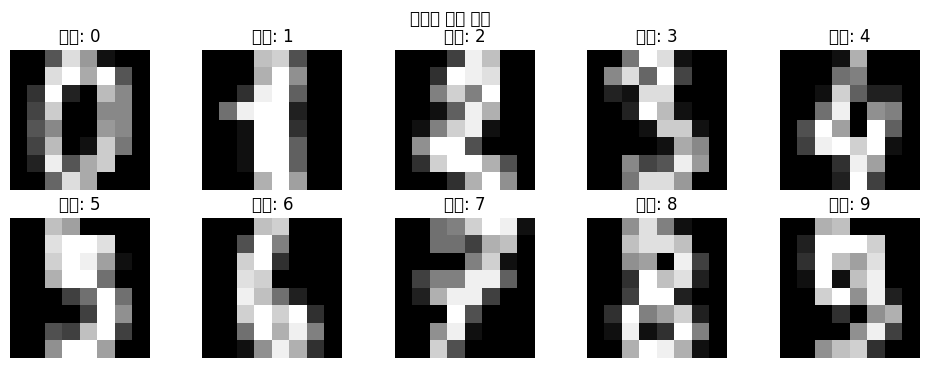

In [ ]:
from sklearn.datasets import load_digits

# 손글씨 숫자 데이터 로드
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"데이터 형태: {X_digits.shape}")
print(f"클래스 수: {len(np.unique(y_digits))}")

# 데이터 시각화
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f'숫자: {digits.target[i]}')
    plt.axis('off')
plt.suptitle('손글씨 숫자 샘플')
plt.show()


MNIST data set

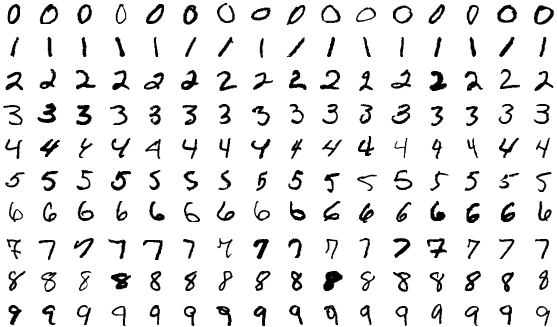

In [ ]:
# 데이터 분할 및 정규화
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_digits, y_digits, test_size=0.2)

In [ ]:
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.fit_transform(X_test_d)

In [ ]:
knn_d = KNeighborsClassifier(n_neighbors=9)
knn_d.fit(X_train_d_scaled, y_train_d)

KNeighborsClassifier(n_neighbors=9)

In [ ]:
# for 문으로 최적에 n_neighbors 찾는 코드짜기!!!

k_val = [5, 10, 15, 20 , 30, 40, 50 ]
digits_result = []

for k in k_val:
    knn_d = KNeighborsClassifier(n_neighbors=k)
    knn_d.fit(X_train_d_scaled, y_train_d)
    acc_d = knn_d.score(X_test_d_scaled, y_pred_d)
    digits_result.append(acc_d)



In [ ]:
best_val = digits_result[np.argmax(digits_result)]

In [ ]:
best_val

0.8305555555555556

In [ ]:
y_pred_d = knn_d.predict(X_test_d)

In [ ]:
cm = confusion_matrix(y_test_d,y_pred_d )

In [ ]:
cm

array([[34,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 39,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  7, 33,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  3,  1, 29,  0,  0,  0,  0,  1,  0],
       [ 1,  4,  0,  0, 32,  0,  0,  1,  0,  0],
       [ 1,  5,  0,  0,  0, 29,  0,  0,  0,  1],
       [ 0,  2,  0,  0,  0,  0, 29,  0,  0,  0],
       [ 0, 14,  0,  0,  0,  0,  0, 27,  0,  0],
       [ 0, 25,  0,  0,  0,  0,  0,  0, 15,  0],
       [ 0,  3,  0,  0,  0,  0,  0,  0,  0, 23]])

In [ ]:
accracy_d = knn_d.score(X_test_d_scaled, y_pred_d)

In [ ]:
accracy_d

0.825

# 하이퍼파라미터를 잘 설정해야 성능을 높일수있다!!!!

-----

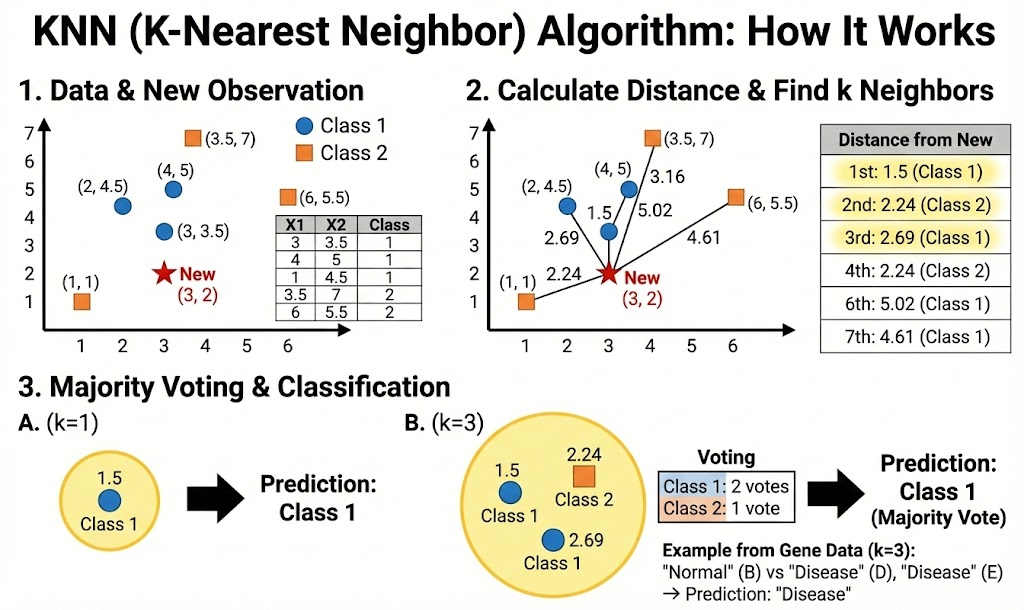

In [ ]:
import numpy as np
from collections import Counter

class simpleKNN:
    def __init__(self, k = 3):
        self.k = k
        self.X_train = None
        self.y_train = None


    def fit(self, X,y): #학습과정이 따로없음 데이터만 저장해둠!!
        self.X_train = np.array(X)
        self.y_train = np.array(y)


    def predict(self, X_new):
        predictions = []

        for x in X_new:

            #1. 거리계산 *유클리드거리

            distance = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

            #2. 가까운 k개의 이웃 찾기
            print(self.k)
            print(distance)

            k_indices = np.argsort(distance)[:self.k]
            #3. 해당 인덱스 라벨(class)

            #라벨링을 불러오는 작업
            k_indices_labels = self.y_train[k_indices]

            most_common = Counter(k_indices_labels).most_common(1)
            predictions.append(most_common[0][0])


            print(f"{self.k} 근접이웃수")
            print(f"{distance} 거리")
            print(f"{self.k} 개의 인덱스:{k_indices} ")
            print(f" 예측결과 {most_common[0][0]} ")


        return np.array(predictions)






In [ ]:
x_train = [[3,3.5],[4,5],[1,4.5],[3.5,7],[6,5.5]]
y_train = [1,1,1,2,2]

knn = s

In [ ]:
knn = simpleKNN(k=3)

In [ ]:
knn.fit(x_train, y_train)

In [ ]:
X_new = [[3,2]]

result = knn.predict(X_new)

3
[1.5        3.16227766 3.20156212 5.02493781 4.60977223]
3 근접이웃수
[1.5        3.16227766 3.20156212 5.02493781 4.60977223] 거리
3 개의 인덱스:[0 1 2] 
 예측결과 1 
